In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df=pd.read_csv("ASGN1/HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [19]:
print(df.isna().sum())
print(df.shape)
df=df.dropna()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64
(506, 14)


In [20]:
print(df.shape)

(394, 14)


In [21]:
from sklearn.model_selection import train_test_split
X=df.drop('MEDV',axis=1)
Y=df['MEDV']
x_train,x_test,y_train,y_test=train_test_split(X,Y)

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [31]:
model=Sequential()
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='linear'))
model.compile(loss='mae',optimizer='adam',metrics=['mse','mae','accuracy'])

In [32]:
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
10/10 [==============================] - 1s 5ms/step - loss: 21.8740 - mse: 561.5389 - mae: 21.8740 - accuracy: 0.0000e+00
Epoch 2/50
10/10 [==============================] - 0s 5ms/step - loss: 21.4478 - mse: 543.5753 - mae: 21.4478 - accuracy: 0.0000e+00
Epoch 3/50
10/10 [==============================] - 0s 5ms/step - loss: 21.0234 - mse: 526.0620 - mae: 21.0234 - accuracy: 0.0000e+00
Epoch 4/50
10/10 [==============================] - 0s 5ms/step - loss: 20.5789 - mse: 508.3926 - mae: 20.5789 - accuracy: 0.0000e+00
Epoch 5/50
10/10 [==============================] - 0s 5ms/step - loss: 20.1096 - mse: 490.0664 - mae: 20.1096 - accuracy: 0.0000e+00
Epoch 6/50
10/10 [==============================] - 0s 4ms/step - loss: 19.6000 - mse: 470.4915 - mae: 19.6000 - accuracy: 0.0000e+00
Epoch 7/50
10/10 [==============================] - 0s 5ms/step - loss: 19.0344 - mse: 449.9493 - mae: 19.0344 - accuracy: 0.0000e+00
Epoch 8/50
10/10 [==============================] - 0s 5ms/ste

In [33]:
model.evaluate(x_test, y_test)

4/4 [==============================] - 0s 6ms/step - loss: 6.4437 - mse: 82.1297 - mae: 6.4437 - accuracy: 0.0000e+00


[6.443655967712402, 82.12972259521484, 6.443655967712402, 0.0]

In [34]:
y_pred=model.predict(x_test)
y_pred=np.array(y_pred).reshape(-1,1)
y_test=np.array(y_test).reshape(-1,1)

4/4 [==============================] - 0s 4ms/step


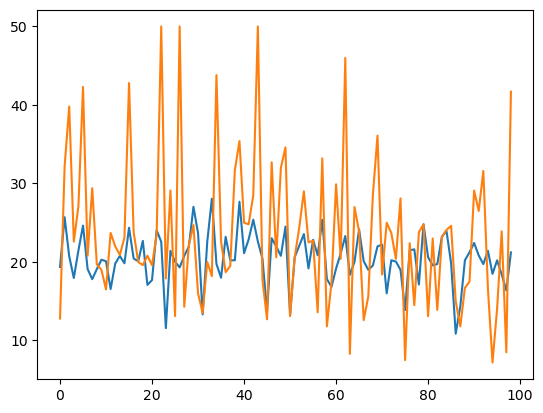

In [35]:
plt.plot(y_pred,label='Predicted')
plt.plot(y_test,label='Actual')